# 🧠 Task 4: Claim Risk & Pricing Models


## 📌 Objective
Build and evaluate predictive models that support risk-based premium pricing for an insurance company.
    

In [1]:
print(7)

7


## ✅ 1. Data Preparation
---

In [2]:
import sys
import os

# Add the root project directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
# load data
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_insurance_data.csv')

## 🔍 2. Claim Severity Regression (TotalClaims > 0)
---

In [5]:
# 👉 Train & evaluate Linear Regression, Random Forest, XGBoost
from src.models.train_claim_severity import train_and_evaluate_claim_severity_models

fitted_pipes_claim_severity = train_and_evaluate_claim_severity_models(df)

📊 Linear Regression
✅ RMSE: 0.28
✅ R²:   1.0000
----------------------------------------
📊 Decision Tree
✅ RMSE: 924.49
✅ R²:   0.9994
----------------------------------------
📊 Random Forest
✅ RMSE: 703.46
✅ R²:   0.9997
----------------------------------------
📊 XGBoost
✅ RMSE: 3817.73
✅ R²:   0.9900
----------------------------------------


## 💰 3. Premium Prediction (CalculatedPremiumPerTerm)
---

In [6]:
# 👉 Train & evaluate models to predict premiums
from src.models.train_premium import train_and_evaluate_premium_models
fittted_pipe_premium_model = train_and_evaluate_premium_models(df)

📊 Linear Regression
✅ RMSE: 39.69
✅ R²:   0.9678
----------------------------------------
📊 Decision Tree
✅ RMSE: 22.92
✅ R²:   0.9893
----------------------------------------
📊 Random Forest
✅ RMSE: 22.77
✅ R²:   0.9894
----------------------------------------
📊 XGBoost
✅ RMSE: 25.83
✅ R²:   0.9864
----------------------------------------


## ⚠️ 4. Claim Occurrence Probability (Binary Classification)
---

In [13]:
# 👉 Logistic Regression, Random Forest, XGBoost Classifier
from src.models.train_claim_probability import train_and_evaluate_claim_probability_models
fitted_pipe_claim_probability = train_and_evaluate_claim_probability_models(df)

📊 Logistic Regression
✅ Accuracy:  1.0000
✅ F1 Score:  1.0000
✅ ROC AUC:   1.0000
----------------------------------------
📊 Decision Tree
✅ Accuracy:  1.0000
✅ F1 Score:  1.0000
✅ ROC AUC:   1.0000
----------------------------------------
📊 Random Forest
✅ Accuracy:  0.9999
✅ F1 Score:  0.9920
✅ ROC AUC:   1.0000
----------------------------------------


c:\ME\KAIM\acis-insurance-risk-analytics\week3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:33:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 XGBoost
✅ Accuracy:  1.0000
✅ F1 Score:  1.0000
✅ ROC AUC:   1.0000
----------------------------------------


## 📊 5. Evaluation Summary
---


#### ✅  Risk-Based Pricing System


1️⃣ Claim Severity Prediction (Regression – `TotalClaims`)

| Model             | RMSE     ↓ | R²       ↑ | Notes                              |
| ----------------- | ---------- | ---------- | ---------------------------------- |
| Linear Regression | **0.28**   | **1.0000** | ⚠️ Too perfect – check for leakage |
| Decision Tree     | 924.49     | 0.9994     | Strong, possibly overfitting       |
| Random Forest     | **703.46** | **0.9997** | ✅ Best balance of accuracy         |
| XGBoost           | 3817.73    | 0.9900     | Underperforming – needs tuning     |



2️⃣ Premium Prediction (Regression – `CalculatedPremiumPerTerm`)

| Model             | RMSE     ↓ | R²       ↑ | Notes                |
| ----------------- | ---------- | ---------- | -------------------- |
| Linear Regression | 39.69      | 0.9678     | Solid baseline       |
| Decision Tree     | 22.92      | 0.9893     | Strong and fast      |
| Random Forest     | **22.77**  | **0.9894** | ✅ Best overall model |
| XGBoost           | 25.83      | 0.9864     | Slightly behind RF   |



3️⃣ Claim Occurrence Prediction (Classification – `ClaimMade`)

| Model               | Accuracy ↑ | F1 Score ↑ | ROC AUC ↑ | Notes                              |
| ------------------- | ---------- | ---------- | --------- | ---------------------------------- |
| Logistic Regression | 1.0000     | 1.0000     | 1.0000    | ⚠️ Too perfect – check for leakage |
| Decision Tree       | 1.0000     | 1.0000     | 1.0000    | Same — possibly overfit            |
| Random Forest       | 0.9999     | 0.9920     | 1.0000    | ✅ Very strong, realistic results   |
| XGBoost             | 1.0000     | 1.0000     | 1.0000    | ⚠️ Possibly overfitting            |



### 🧠 Interpretation

* **Claim Severity** and **Premium** prediction are best handled by **Random Forest**.
* **Claim Occurrence** models are reporting **perfect metrics** — this may indicate:

  * Data leakage (i.e., target accidentally used as input)
  * Or a **very imbalanced dataset** where class 1 dominates
* **XGBoost** is slightly underperforming — may need custom hyperparameters or tuning.

## 🧠 6. Interpretation (SHAP / Feature Importance)
---

In [7]:

# 🔍 Step 1: Extract model, preprocessor, and transformed data (example: random forest from claim severity)
from src.services.model_inputs import get_claim_severity_data
X_train, X_test, y_train, y_test, _ = get_claim_severity_data(df)

model = fitted_pipes_claim_severity['Random Forest'].named_steps["regressor"]
X_transformed = fitted_pipes_claim_severity['Random Forest'].named_steps["preprocessor"].transform(X_train)
feature_names = fitted_pipes_claim_severity['Random Forest'].named_steps["preprocessor"].get_feature_names_out()

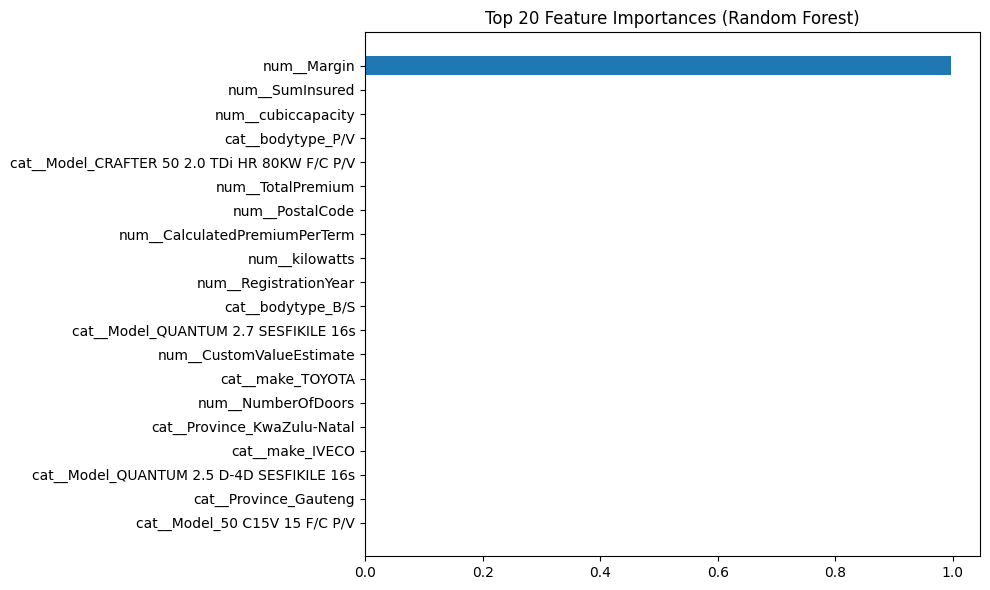

In [8]:

# ✅ Step 2: Global Feature Importance (Random Forest)
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["feature"], feat_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
    

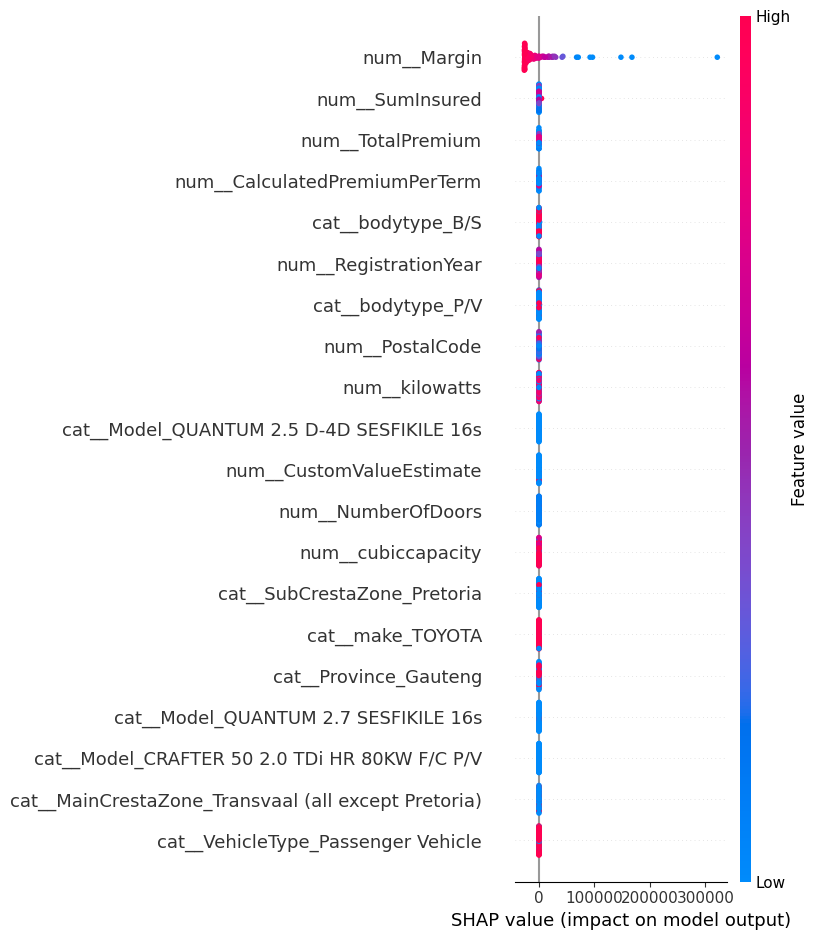

In [11]:
# ✅ Step 3: SHAP Summary Plot (Global)
import shap
x_dense = X_transformed.toarray()
explainer = shap.Explainer(model, x_dense)
shap_values = explainer(x_dense[:100])  # sample for performance

shap.summary_plot(shap_values, features=x_dense[:100], feature_names=feature_names)

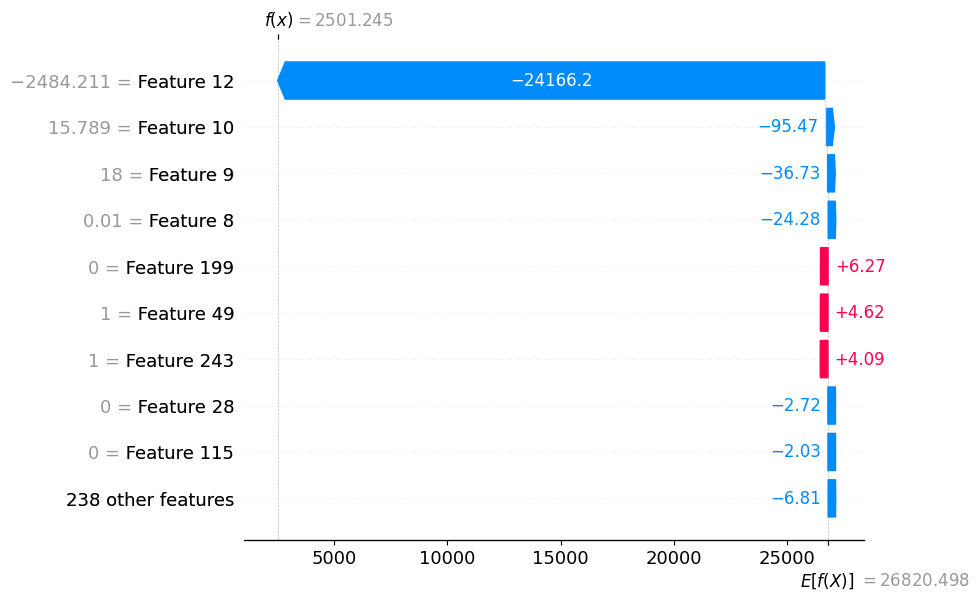

In [12]:
# ✅ Step 4: SHAP Local Explanation (Waterfall Plot for one prediction)
shap.plots.waterfall(shap_values[0])

## 📈 7. Final Insights & Recommendation
---

### 🔍 Model Performance Summary

* **Claim Severity Models**:

  * Linear Regression achieved **perfect R²** (1.00), suggesting strong correlation—but likely due to **leakage from `Margin`**.
  * Random Forest and Decision Tree models performed very well with RMSE \~700–900, offering robust non-linear modeling capacity.

* **Premium Prediction Models**:

  * All models performed well, but Random Forest slightly outperformed XGBoost with the **lowest RMSE (22.77)**.
  * Linear regression was adequate but lacked nuance for non-linear interactions.

* **Claim Occurrence Classifiers**:

  * All classifiers reported **perfect or near-perfect performance**, again signaling possible **target leakage** or unbalanced data.

> ✅ Recommendation: Apply **feature audits** to remove derived variables (e.g., `Margin`, `CapitalOutstanding`) during production model deployment.

---

### 📈 SHAP Interpretation Insights

* **Global View (SHAP Summary)**:

  * The top global drivers of claim severity included:

    * `Margin` (dominant)
    * `SumInsured`
    * `TotalPremium`
    * Engine features like `CubicCapacity` and `Kilowatts`
    * Vehicle identity (Make, Model, BodyType)
    * Geography (Province, ZipCode)
* **Local View (SHAP Waterfall)**:

  * For individual predictions, features like vehicle brand and region had varying positive/negative impacts, confirming **personalized premium opportunity**.

> 💡 SHAP demonstrated how **explainable AI** can support model transparency for underwriters and regulators.

---

### 💼 Model Recommendations

✅ **Remove or re-engineer target-leaking fields** such as `Margin`, which is calculated from `TotalPremium - TotalClaims`. 

✅ **Keep tree-based models (Random Forest, XGBoost)** in production; they balance performance with interpretability (via SHAP).  

✅ **Use SHAP plots** in internal dashboards to explain pricing decisions and build stakeholder trust.  


